In [1]:
from IPython import get_ipython
import sys, os

ipython = get_ipython()
ipython.magic('load_ext autoreload')
ipython.magic('autoreload 2')
sys.path.append(os.path.abspath(os.path.join('..')))

from os.path import join
from src import mine
from src.io.reader import Setting, Reader, Series
import argparse, pprint
import pandas as pd
import xlrd
xlrd.xlsx.ensure_elementtree_imported(False, None)
from IPython.display import display, HTML
import itertools
import time
from src.time_series  import  timeseries 
from typing import NamedTuple
from os.path import join
import pandas as pd
import math
import numpy as np
import xlrd
xlrd.xlsx.ensure_elementtree_imported(False, None)
xlrd.xlsx.Element_has_iter = True
xlrd.xlsx.Element_has_iter = True
from src.optimization.opt_model import OptModel
from src.optimization.functions import BoundRules, ConstraintRules, ObjectiveRules, OptSets

C:\Users\dlira\AppData\Local\Temp\ipykernel_40920\2617934898.py:5: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  ipython.magic('load_ext autoreload')
C:\Users\dlira\AppData\Local\Temp\ipykernel_40920\2617934898.py:6: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  ipython.magic('autoreload 2')


In [2]:
print(np.__version__)

1.26.4


In [2]:
class Parameters(NamedTuple):
    """ Define a MOC class which contains default values
    from program model simulation 
    
    """
    selected = 'Case1'
    model = join('..', 'data', 'C:\\Users\\dlira\\OneDrive\\Escritorio\\ELMO-UG-main-year\\data\\data_efficient_var\\elmo_data.xlsx')
    series = join('..', 'data', 'C:\\Users\\dlira\OneDrive\\Escritorio\\ELMO-UG-main-year\\data\\data_efficient_var\\time_series.xlsx')


In [3]:
args = Parameters()
model = Reader(args.model, start_in=1)
series = Series(args.series)

In [4]:
shifts=series['Shifts']
shifts[['id','name','day_start','hour_start','duration']]

,id,name,day_start,hour_start,duration
0,1,shift_1_1,1,0,6.5
1,2,shift_1_2,1,8,6.5
2,3,shift_1_3,1,16,6.5
3,4,shift_2_1,2,0,6.5
4,5,shift_2_2,2,8,6.5
...,...,...,...,...,...
1090,1091,shift_364_2,364,8,6.5
1091,1092,shift_364_3,364,16,6.5
1092,1093,shift_365_1,365,0,6.5
1093,1094,shift_365_2,365,8,6.5


In [5]:
time_series=timeseries.Timeseries(series, [1],0.5)
mine_system = mine.Mine(model)


In [14]:
print(time_series.get_trips(mine_system))

KeyError: 'distance_to_d_node_outbound'

In [6]:
time_series.mapper['Trips']=time_series.get_trips(mine_system)
time_series.mapper['Trips']

KeyError: 'distance_to_d_node_outbound'

In [7]:
mine_system.layout.get_street('ex_node_0')


'street_1'

In [8]:
time_series.mapper['Intervals2Shift']

KeyError: 'Intervals2Shift'

In [9]:
shift_name='shift_1_1'
elhd_name='LH518B_1'
node_list=time_series.get_nodes_assigned_to_elhd(shift_name,elhd_name)
node_list
#exists = 'ex_node_20' in node_list
#exists

TypeError: Timeseries.get_nodes_assigned_to_elhd() missing 1 required positional argument: 'elhd_name'

In [10]:
shift_name='shift_1_1'
time_series.get_shift_start_interval(shift_name)
#n_shifts=Time_series.get_number_of_shifts()
time_series.shifts



['shift_1_1', 'shift_1_2', 'shift_1_3']

In [11]:
time_series.mapper['ExtractionGoal']
time_series.get_extraction_goal('ex_node_0', 1)

320

In [12]:
time_series.mapper['MarginalCost']
location_name='Profile_Chuquicamata110'
time_interval=4
time_series.get_marginal_cost(location_name,time_interval)


TypeError: Timeseries.get_marginal_cost() missing 1 required positional argument: 'time_interval'

In [16]:
day=1
shift_id=1
time_series.get_number_of_shifts()

3

In [17]:
delta_t=0.5
time_series.get_time_intervals()



[               interval
 day shifts             
 1.0 shift_1_1       1.0
     shift_1_1       2.0
     shift_1_1       3.0
     shift_1_1       4.0
     shift_1_1       5.0
     shift_1_1       6.0
     shift_1_1       7.0
     shift_1_1       8.0
     shift_1_1       9.0
     shift_1_1      10.0
     shift_1_1      11.0
     shift_1_1      12.0
     shift_1_1      13.0
     shift_1_1      14.0
     shift_1_1      15.0
     shift_1_1      16.0
     shift_1_2      17.0
     shift_1_2      18.0
     shift_1_2      19.0
     shift_1_2      20.0
     shift_1_2      21.0
     shift_1_2      22.0
     shift_1_2      23.0
     shift_1_2      24.0
     shift_1_2      25.0
     shift_1_2      26.0
     shift_1_2      27.0
     shift_1_2      28.0
     shift_1_2      29.0
     shift_1_2      30.0
     shift_1_2      31.0
     shift_1_2      32.0
     shift_1_3      33.0
     shift_1_3      34.0
     shift_1_3      35.0
     shift_1_3      36.0
     shift_1_3      37.0
     shift_1_3      38.0


In [13]:
elhd_name='LH518B_1'
node_name='ex_node_0'
time_series.get_n_trips(node_name, elhd_name)

KeyError: 'Trips'

In [19]:
t=1
elhd='LH518B_1'
node_assignment.loc['shift_1_3', elhd]['ex_node_name']

shift_name  elhd_name
shift_1_3   LH518B_1     ex_node_0
            LH518B_1     ex_node_1
            LH518B_1     ex_node_2
            LH518B_1     ex_node_3
            LH518B_1     ex_node_4
            LH518B_1     ex_node_5
            LH518B_1     ex_node_6
            LH518B_1     ex_node_7
Name: ex_node_name, dtype: object

In [20]:
import pyomo.environ as pyo

In [21]:
constraint_rules = ConstraintRules(mine_system,time_series)
objective_rules = ObjectiveRules(mine_system,time_series)
bound_rules = BoundRules(mine_system,time_series)
set_builder = OptSets(mine_system,time_series)



c:\Users\dlira\Desktop\ELMO-UG\src\time_series\timeseries.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  shift_name = self.mapper['Intervals2Shift'].loc[interval][0]


In [22]:
mine_system.layout.data

,id,node_name,street,discharge_node,distance_to_d_node,quota,tilt
node_name,,,,,,,
ex_node_0,0,ex_node_0,street_1,d_node_0,30,1000,0
ex_node_1,1,ex_node_1,street_1,d_node_0,30,1000,0
ex_node_10,10,ex_node_10,street_2,d_node_0,110,1000,0
ex_node_11,11,ex_node_11,street_2,d_node_0,40,1000,0
ex_node_12,12,ex_node_12,street_2,d_node_0,60,1000,0
ex_node_13,13,ex_node_13,street_2,d_node_0,60,1000,0
ex_node_14,14,ex_node_14,street_2,d_node_0,80,1000,0
ex_node_15,15,ex_node_15,street_2,d_node_0,80,1000,0
ex_node_16,16,ex_node_16,street_2,d_node_0,100,1000,0


In [23]:
[0]+time_series.time_intervals

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48.])

In [24]:
model = pyo.ConcreteModel()
set_builder.build_sets(model)

model.pprint()

5 Set Declarations
    elhd_set : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    5 : {'LH518B_1', 'LH518B_2', 'LH518B_3', 'LH518B_4', 'R1700 XE_5'}
    nodes_set : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   40 : {'ex_node_0', 'ex_node_1', 'ex_node_10', 'ex_node_11', 'ex_node_12', 'ex_node_13', 'ex_node_14', 'ex_node_15', 'ex_node_16', 'ex_node_17', 'ex_node_18', 'ex_node_19', 'ex_node_2', 'ex_node_20', 'ex_node_21', 'ex_node_22', 'ex_node_23', 'ex_node_24', 'ex_node_25', 'ex_node_26', 'ex_node_27', 'ex_node_28', 'ex_node_29', 'ex_node_3', 'ex_node_30', 'ex_node_31', 'ex_node_32', 'ex_node_33', 'ex_node_34', 'ex_node_35', 'ex_node_36', 'ex_node_37', 'ex_node_38', 'ex_node_39', 'ex_node_4', 'ex_node_5', 'ex_node_6', 'ex_node_7', 'ex_node_8', 'ex_node_9'}
    time_intervals_between_shifts_set : Size=1, Index=None, Ordered=Insertion
        Ke

In [25]:
time_series.mapper['Nodes_assigned_at_interval'][(16.0, 'LH518B_1')]

['ex_node_0',
 'ex_node_1',
 'ex_node_2',
 'ex_node_3',
 'ex_node_4',
 'ex_node_5',
 'ex_node_6',
 'ex_node_7']

In [26]:
shift_name='shift_1_1'
elhd_name='LH518B_1'
list([node_assignment.loc[shift_name, elhd_name]['ex_node_name']])

[shift_name  elhd_name
 shift_1_1   LH518B_1     ex_node_0
             LH518B_1     ex_node_1
             LH518B_1     ex_node_2
             LH518B_1     ex_node_3
             LH518B_1     ex_node_4
             LH518B_1     ex_node_5
             LH518B_1     ex_node_6
             LH518B_1     ex_node_7
 Name: ex_node_name, dtype: object]

In [27]:
time_series.get_trips(mine_system)


print(time_series.get_energy_consumption('ex_node_0' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_1' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_2' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_3' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_4' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_5' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_6' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_7' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_8' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_9' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_10' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_11' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_12' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_13' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_14' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_15' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_16' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_17' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_18' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_19' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_20' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_21' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_22' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_23' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_24' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_25' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_26' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_27' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_28' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_29' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_30' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_31' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_32' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_33' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_34' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_35' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_36' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_37' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_38' , 'LH518B_1' ))
print(time_series.get_energy_consumption('ex_node_39' , 'LH518B_1' ))


2.4015215587759227
2.4015215587759227
2.4015215587759227
2.7646694966651584
2.7646694966651584
3.127817434554394
3.127817434554394
3.49096537244363
3.49096537244363
3.8541133103328655
3.8541133103328655
2.5830955277205403
2.9462434656097765
2.9462434656097765
3.3093914034990117
3.3093914034990117
3.6725393413882474
3.6725393413882474
4.035687279277483
4.035687279277483
4.398835217166719
3.127817434554394
3.49096537244363
3.49096537244363
3.8541133103328655
3.8541133103328655
4.217261248222101
4.217261248222101
4.5804091861113365
4.5804091861113365
4.943557124000574
3.6725393413882474
4.035687279277483
4.035687279277483
4.398835217166719
4.398835217166719
4.761983155055955
4.761983155055955
5.125131092945191
5.125131092945191


In [4]:
print(time_series.get_trips(mine_system).to_string())

NameError: name 'time_series' is not defined

In [69]:
print(mine_system.elhd.get_per_trip_info(180,0,'LH518B_1'))

(178.11851851851856, 4.7810293386814315)


In [28]:
j='ex_node_0'
i='LH518B_1'
distance = mine_system.layout.get_distance_to_d_node(j)


In [29]:
bound_rules.build_all_variables(model)
model.E.pprint()

E : Size=245, Index=elhd_set*time_intervals_set_zero
    Key                  : Lower : Value : Upper : Fixed : Stale : Domain
         ('LH518B_1', 0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 1.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 2.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 3.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 4.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 5.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 6.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 7.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 8.0) :     0 :  None :   353 : False :  True :  Reals
       ('LH518B_1', 9.0) :     0 :  None :   353 : False :  True :  Reals
      ('LH518B_1', 10.0) :     0 :  None :   353 : False :  True :  Reals
      ('LH518B_1', 11.0) :     0 :  None :   353 : False : 

In [30]:
model.max_power = pyo.Constraint(model.elhd_set, model.time_intervals_set, rule=constraint_rules.max_power)
model.max_power['LH518B_1',48.0].pprint()

{Member of max_power} : Size=240, Index=elhd_set*time_intervals_set, Active=True
    Key                : Lower : Body                                    : Upper : Active
    ('LH518B_1', 48.0) :  -Inf : P[LH518B_1,48.0] - 360*Z[LH518B_1,48.0] :   0.0 :   True


In [31]:
model.bat_lower_bound = pyo.Constraint(model.elhd_set, model.time_intervals_set, rule=constraint_rules.bat_lower_bound)       
model.bat_lower_bound['LH518B_1',48.0].pprint()

{Member of bat_lower_bound} : Size=240, Index=elhd_set*time_intervals_set, Active=True
    Key                : Lower             : Body             : Upper : Active
    ('LH518B_1', 48.0) : 70.60000000000001 : E[LH518B_1,48.0] :  +Inf :   True


In [32]:
model.bat_upper_bound = pyo.Constraint(model.elhd_set, model.time_intervals_set, rule=constraint_rules.bat_upper_bound)
model.bat_upper_bound['LH518B_1',48.0].pprint()

{Member of bat_upper_bound} : Size=240, Index=elhd_set*time_intervals_set, Active=True
    Key                : Lower : Body             : Upper : Active
    ('LH518B_1', 48.0) :  -Inf : E[LH518B_1,48.0] : 353.0 :   True


In [33]:
model.elhd_soc = pyo.Constraint(model.elhd_set, model.time_intervals_set_zero, rule=constraint_rules.elhd_soc)

In [34]:
model.state_change = pyo.Constraint(model.elhd_set,model.nodes_set, model.time_intervals_set,
                                            rule=constraint_rules.state_change)


In [35]:
model.elhd_state_c = pyo.Constraint(model.elhd_set, model.time_intervals_set, rule=constraint_rules.elhd_state_c)
model.elhd_state_c['LH518B_1',1.0].pprint()


{Member of elhd_state_c} : Size=240, Index=elhd_set*time_intervals_set, Active=True
    Key               : Lower : Body                                                                                                                                                                                                                                            : Upper : Active
    ('LH518B_1', 1.0) :   1.0 : Y[LH518B_1,ex_node_0,1.0] + Y[LH518B_1,ex_node_1,1.0] + Y[LH518B_1,ex_node_2,1.0] + Y[LH518B_1,ex_node_3,1.0] + Y[LH518B_1,ex_node_4,1.0] + Y[LH518B_1,ex_node_5,1.0] + Y[LH518B_1,ex_node_6,1.0] + Y[LH518B_1,ex_node_7,1.0] + Z[LH518B_1,1.0] :   1.0 :   True


In [36]:
model.end_travel = pyo.Constraint(model.elhd_set, model.nodes_set, model.time_intervals_set, rule=constraint_rules.end_travel)
model.end_travel['LH518B_1','ex_node_0',1.0].pprint()

{Member of end_travel} : Size=1880, Index=elhd_set*nodes_set*time_intervals_set, Active=True
    Key                            : Lower : Body                                                        : Upper : Active
    ('LH518B_1', 'ex_node_0', 1.0) :   0.0 : Yini[LH518B_1,ex_node_0,1.0] - Yfin[LH518B_1,ex_node_0,2.0] :   0.0 :   True


In [37]:
model.force_duration = pyo.Constraint(model.elhd_set, model.nodes_set, model.time_intervals_set,rule=constraint_rules.force_duration)
model.force_duration['LH518B_1','ex_node_0',1.0].pprint()


{Member of force_duration} : Size=1920, Index=elhd_set*nodes_set*time_intervals_set, Active=True
    Key                            : Lower : Body                                                     : Upper : Active
    ('LH518B_1', 'ex_node_0', 1.0) :  -Inf : Yini[LH518B_1,ex_node_0,1.0] - Y[LH518B_1,ex_node_0,1.0] :   0.0 :   True


In [38]:
model.between_shifts = pyo.Constraint(model.elhd_set, model.time_intervals_between_shifts_set, rule=constraint_rules.between_shifts)
model.between_shifts.pprint()

between_shifts : Size=15, Index=elhd_set*time_intervals_between_shifts_set, Active=True
    Key                  : Lower : Body               : Upper : Active
      ('LH518B_1', 16.0) :   1.0 :   Z[LH518B_1,16.0] :   1.0 :   True
      ('LH518B_1', 32.0) :   1.0 :   Z[LH518B_1,32.0] :   1.0 :   True
      ('LH518B_1', 48.0) :   1.0 :   Z[LH518B_1,48.0] :   1.0 :   True
      ('LH518B_2', 16.0) :   1.0 :   Z[LH518B_2,16.0] :   1.0 :   True
      ('LH518B_2', 32.0) :   1.0 :   Z[LH518B_2,32.0] :   1.0 :   True
      ('LH518B_2', 48.0) :   1.0 :   Z[LH518B_2,48.0] :   1.0 :   True
      ('LH518B_3', 16.0) :   1.0 :   Z[LH518B_3,16.0] :   1.0 :   True
      ('LH518B_3', 32.0) :   1.0 :   Z[LH518B_3,32.0] :   1.0 :   True
      ('LH518B_3', 48.0) :   1.0 :   Z[LH518B_3,48.0] :   1.0 :   True
      ('LH518B_4', 16.0) :   1.0 :   Z[LH518B_4,16.0] :   1.0 :   True
      ('LH518B_4', 32.0) :   1.0 :   Z[LH518B_4,32.0] :   1.0 :   True
      ('LH518B_4', 48.0) :   1.0 :   Z[LH518B_4,48.0] :   1.

In [39]:
model.boundary_constraint = pyo.Constraint(model.elhd_set, rule=constraint_rules.boundarie_constraint)
model.boundary_constraint['LH518B_1'].pprint()

{Member of boundary_constraint} : Size=5, Index=elhd_set, Active=True
    Key      : Lower : Body                             : Upper : Active
    LH518B_1 :   0.0 : E[LH518B_1,0] - E[LH518B_1,48.0] :   0.0 :   True


In [40]:
j='ex_node_0'
day=1
time_series.get_extraction_goal(j,day) 

500.0

In [41]:
model.mineral_demand= pyo.Constraint(time_series.days,model.nodes_set, rule=constraint_rules.mineral_demand)
model.mineral_demand[1,'ex_node_0'].pprint()

{Member of mineral_demand} : Size=40, Index={1}*nodes_set, Active=True
    Key              : Lower : Body                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [42]:
from pyomo.opt import SolverFactory

In [43]:
model.obj = pyo.Objective(rule=objective_rules.objective)

In [44]:
# Crear una instancia del solver
solver = SolverFactory('gurobi', solver_io="python")

# Ajusta la tolerancia de optimalidad al 5%
solver.options['MIPGap'] = 0.005
solver.options['LogToConsole'] = 1
solver.options['Method'] = 2
solver.options['LogToConsole'] = 1
solver.options['OutputFlag'] = 1
filename = 'model.lp'
model.write(filename, io_options={'symbolic_solver_labels': True})
# Resolver el modelo
result = solver.solve(model)

# Imprimir el estado de la solución
print('Termination condition:', result.solver.termination_condition)

# Obtener el valor de la solución factible
feasible_value = pyo.value(model.obj)
print("Feasible value: {:.3f}".format(feasible_value))



Set parameter OutputFlag to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1345U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 6980 rows, 29525 columns and 22945 nonzeros
Model fingerprint: 0x3917c380
Variable types: 485 continuous, 29040 integer (29040 binary)
Coefficient statistics:
  Matrix range     [5e-01, 5e+02]
  Objective range  [6e-02, 3e-01]
  Bounds range     [1e+00, 4e+02]
  RHS range        [1e+00, 5e+02]
Presolve removed 6677 rows and 28157 columns
Presolve time: 1.08s
Presolved: 303 rows, 1368 columns, 3807 nonzeros
Variable types: 288 continuous, 1080 integer (1080 binary)
Found heuristic solution: objective 1021.2060263
Root barrier log...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 2.439e+03
 Factor NZ  : 5.328e+03 (roughly 1 MB of memory)
 Factor Ops : 1.059e+05 (less than 1 second p

In [45]:
#from gurobipy import *
#model = read("model.lp")
#model.computeIIS()

In [46]:
#model.write('iismodel.ilp')

In [47]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import networkx as nx

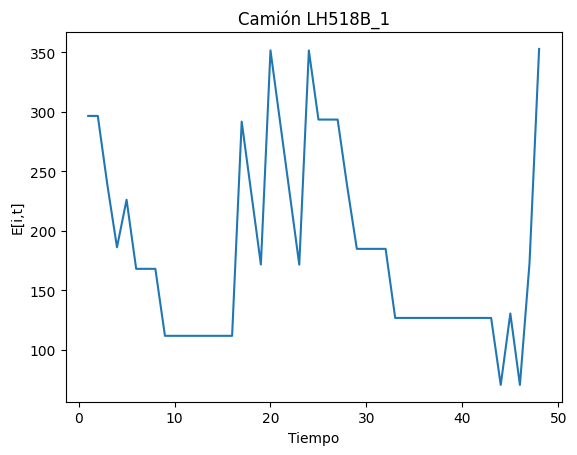

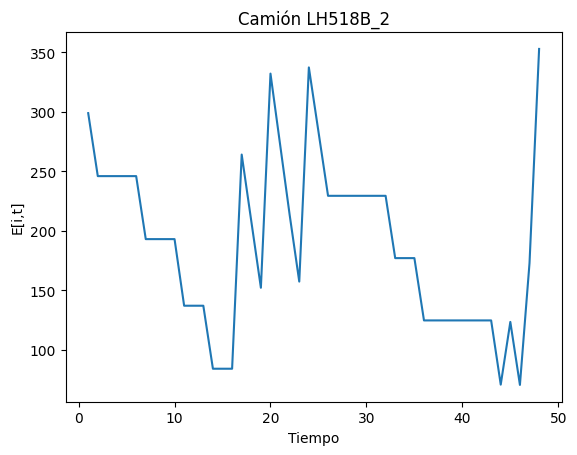

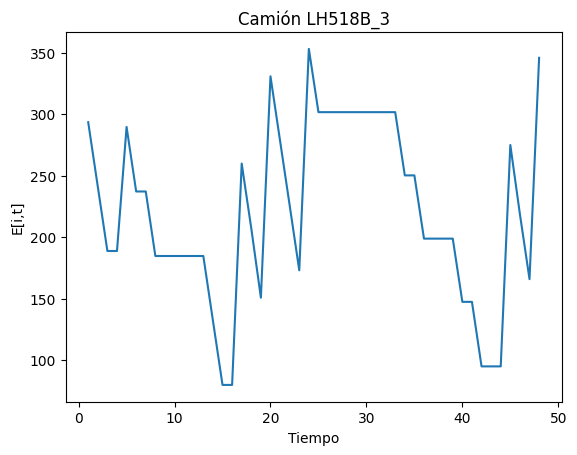

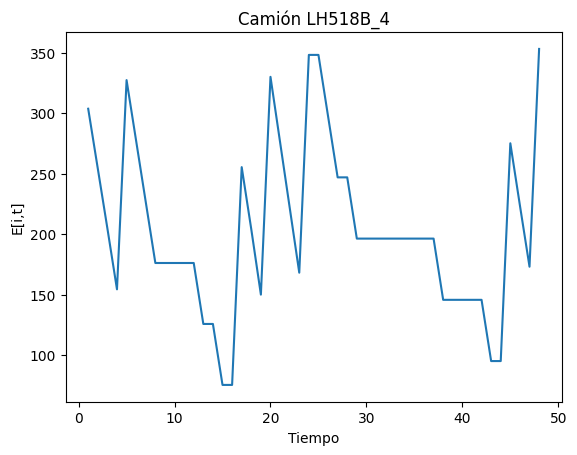

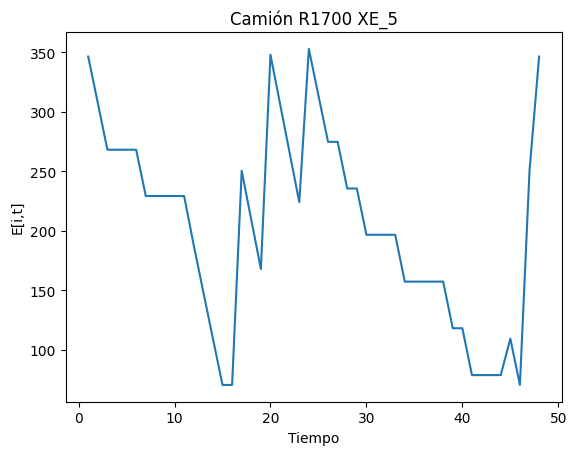

In [48]:
for i in model.elhd_set:
    # Crear una lista para almacenar los valores de E[i,t]
    E_values = [model.E[i,t].value for t in model.time_intervals_set]

    # Crear un gráfico
    plt.figure()
    plt.plot(model.time_intervals_set, E_values)
    plt.title(f'Camión {i}')
    plt.xlabel('Tiempo')
    plt.ylabel('E[i,t]')
    plt.show()

In [49]:
node='ex_node_0'
elhd_name='LH518B_1'
distance=mine_system.layout.get_distance_to_d_node(node)
tilt=mine_system.layout.get_tilt(node)
t_travel, t_acc,t_dec,t_constant=[164.12,0.321,0.321,29.35]

In [50]:
print(mine_system.elhd.aerodynamic_loss(elhd_name, t_acc, t_constant)/(1000*3600))


0.0006097053699100211


In [51]:
print(mine_system.elhd.delta_kinetic_energy(elhd_name)/(1000*3600))

0.13074417009602193


In [52]:
print(mine_system.elhd.rolling_resistance(mine_system.layout,'ex_node_0', 18, elhd_name)/(1000*3600))

AttributeError: 'ELHD' object has no attribute 'rolling_resistance'

In [53]:
constant_speed = mine_system.elhd.get_speed(elhd_name) * (1000 / 3600)
weight_out = mine_system.elhd.get_weight(elhd_name) * 1000  # in kg
weight_return = (mine_system.elhd.get_weight(elhd_name) + mine_system.elhd.get_load_capacity(elhd_name)) * 1000  # in kg
e_outbound = 0.5 * weight_out * constant_speed ** 2
e_return = 0.5 * weight_return * constant_speed ** 2
print(weight_out,weight_return,e_outbound,e_return)

52000 70000 200617.28395061727 270061.72839506174


In [54]:
constant_speed = mine_system.elhd.get_speed(elhd_name) * (1000 / 3600)
acceleration = mine_system.elhd.get_acceleration(elhd_name)
front_area = mine_system.elhd.get_front_area(elhd_name)
rho = 1.225
c_drag = 0.91
constant = 0.5 * rho * front_area * c_drag
loss_acc_term = ((acceleration ** 3) * (t_acc ** 4)) / 4  # \int_{t=0}^{t_acc} v^3 dt where v=a*t
loss_cte_speed_term = constant_speed ** 3 * t_constant  # \int_{t=0}^{t_cte} v^3 dt where v=cte
loss_decc_term = ((acceleration ** 3) * (t_acc ** 4)) / 4  # \int_{t=0}^{t_acc} v^3 dt where v=a*t
constant * (loss_acc_term + loss_cte_speed_term + loss_decc_term)

2194.939331676076

In [55]:
mine_system.elhd.rolling_resistance_loss(elhd_name, tilt, t_acc, t_constant)

4554608.122189556

In [56]:
mine_system.elhd.engine_energy(elhd_name, tilt, t_acc, t_constant)/1000

TypeError: ELHD.engine_energy() missing 2 required positional arguments: 't_load' and 't_unload'

In [57]:
time=t_acc*2+ t_constant
time

29.992

In [ ]:
delta_t*3660/(t_travel)

In [ ]:
65000/40/(10*12)

In [ ]:
(10*12)